### Set Up

In [27]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind
from functools import reduce

In [28]:
# Automatically reload modules when they change
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
scenarios_path = Path().resolve() / "../../scenarios_inputs" / "cheung_variants" 
annotated_output_path = Path().resolve() / "../../annotated_outputs" / "cheung_variants"
plots_path = Path().resolve() / "../../analysis" / "cheung_variants" / "cheung_visualizations"
print(f"scenarios_path: {scenarios_path}")
print(f"annotated_output_path: {annotated_output_path}")



scenarios_path: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../scenarios_inputs/cheung_variants
annotated_output_path: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants


In [30]:
import analysis_utils

### Define Functions

In [31]:
#parse the read in filenames to get the condition and id
def parse_filename(filename):
    #filename is of the form "%s_%d_choice_1.json"
    parts = filename.stem.split("_")
    narrative = parts[0]
    id = int(parts[1])
    return narrative, id

In [32]:
def extract_action(nodes):
    
    value = None

    for node in nodes:
        n = node.get('node',{})
        if n.get('kind') == 'action_choice':
            # print(n.get('label'))
            label = n.get('label')
    
    

    return label

In [33]:
def read_scenario(file_path): 

    narrative, id = parse_filename(file_path)


    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    nodes = [json.loads(line.strip()) for line in lines if line.strip()]

    act_choice = extract_action(nodes)


    # also return original scenario text for reference
    with open(scenarios_path / f"{narrative}.json") as f:

        scenario_list = json.load(f)
        #get the one with the matching id
        this_scenario = next(s for s in scenario_list if s['id'] == id)
     

        #extract the condition from the json read in
        scenario_text = this_scenario['text']
        scenario_deontology = this_scenario['deontology_level']
        scenario_utility = this_scenario['utility_level']
        
    #create a little dictionary with everything in it
    scenario_info = {
        "narrative": narrative,
        "id": id,
        "act": act_choice,
        "text": scenario_text,
        "deontology": scenario_deontology,
        "utility": scenario_utility
    }

    return nodes, scenario_info

In [34]:

def events_to_utility_df(nodes):
  
    util_dfs = []

    for node in nodes:
        n = node.get('node',{})
        if n.get('kind') == 'event':
            links = node.get('links')
            data = {}
            for link in links:
                to_node = link.get('to_node')
                value = link.get('link', {}).get('value')
                data[to_node] = value
                label = n.get('label')
                df = pd.DataFrame([data], index=[label])
            util_dfs.append(df)

    df = pd.concat(util_dfs, ignore_index=False)
    df = df.apply(pd.to_numeric)
    
    return df


In [35]:
def extract_deontology(nodes):
    
    value = None

    for node in nodes:
        n = node.get('node',{})
        if n.get('kind') == 'action_choice':
            # print(n.get('label'))
            links = node.get('links')
            # print(links)
            for link in links:
                    # print(link)
                    if link.get('link', {}).get('kind')=='v-link':
                        value = link.get('link', {}).get('value')
    

    return value

In [36]:
#attempt for a generitc utility function to read the annotation files for a given annotation output json file.
def parse_events_with_labels(file_path):
    """
    Parse a JSON file containing event nodes and extract their C/I/K polarity labels.
    
    Args:
        file_path: Path to the JSON file
        
    Returns:
        dict: Mapping of event labels to their C/I/K polarity strings
              e.g., {"Historical buildings are demolished": "C+I+K+", ...}
    """
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    # Parse each line to create a list of JSON objects
    nodes = [json.loads(line.strip()) for line in lines if line.strip()]
    
    # Find the first being node (first node with kind "being")
    being_node = None
    for node_obj in nodes:
        if node_obj.get('node', {}).get('kind') == 'being':
            being_node = node_obj
            break
    
    if not being_node:
        return {}
    
    # Create a mapping from event labels to their C/I/K values
    event_labels = {}
    
    for link in being_node.get('links', []):
        to_node_label = link.get('to_node')
        b_link_value = link.get('link', {}).get('value')
        
        if to_node_label and b_link_value:
            event_labels[to_node_label] = b_link_value
    
    # Filter to only include actual events
    event_nodes = {
        node_obj['node']['label'] 
        for node_obj in nodes 
        if node_obj.get('node', {}).get('kind') == 'event'
    }
    
    return {label: value for label, value in event_labels.items() if label in event_nodes}

In [37]:
def get_utilities(nodes):

    util_df =  events_to_utility_df(nodes)


    # For each being (column), calculate product of positive and negative utilities across outcomes
    utility_products = {}
    for col in util_df.columns:
        positive_utils = util_df[col][util_df[col] > 0]
        negative_utils = util_df[col][util_df[col] < 0]
        pos_product = reduce(lambda x, y: x * y, positive_utils, 1) if not positive_utils.empty else 0
        neg_product = reduce(lambda x, y: x * y, negative_utils, 1) if not negative_utils.empty else 0
        utility_products[col] = {"positive_product": pos_product, "negative_product": neg_product, "difference": pos_product - neg_product}

        util_mean_df = pd.DataFrame({'mean_utility': util_df.mean()})
    
    return util_mean_df


In [38]:
def single_scenario_analysis(scenario_name, this_id, act_id):

    filename = filename_template % (scenario_name, this_id, act_id)

    file_path = annotated_output_path / filename


    nodes, scenario_dictionary = read_scenario(file_path)
    
    print(f"Read scenario: {file_path}")

    print(f"Scenario number: {scenario_dictionary['id']}")
    print(f"Scenario action choice: {scenario_dictionary['act']}")
    print(f"Scenario utility: {scenario_dictionary['utility']}")
    print(f"Scenario deontology: {scenario_dictionary['deontology']}")
    util_df =  events_to_utility_df(nodes)


    #get the column means for the utility dataframe (per entity)
    print(util_df.mean())

    util_mean = np.mean(util_df.mean())
    print('overall mean: ' + str(util_mean))

    return util_mean

In [39]:

def get_counterfact_util(scenario_id):

    util_mean_1 = single_scenario_analysis(scenario_name, scenario_id,1)
    print('\n\n')
    util_mean_2 = single_scenario_analysis(scenario_name, scenario_id,2)

    util_diff = util_mean_1 -  util_mean_2
    print('\n\nutility difference between choice 1 and choice 2: ' + str(util_diff))

    return util_diff


### Select scenario to analyze

In [125]:
#get all of the json files in the annotated_output_path
SCENARIO_NAME = "bird"
json_files = list(annotated_output_path.glob(f"*{SCENARIO_NAME}*choice_1.json"))
SCENARIO_LIST = list(range(1, int(len(json_files)) + 1))
#note, we assume that there are 2 action ids, where id 1 is the action and id 2 is the counterfactual action. 
filename_template = "%s_%d_choice_%d.json"

### Extract utility and deontology scores from individual scanerios to examine them closely

In [126]:
get_counterfact_util(1)

Read scenario: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/tyrannicide2_1_choice_1.json
Scenario number: 1
Scenario action choice: torture the dictator
Scenario utility: 3
Scenario deontology: 1
i                                                                                                -33.0
the dictator                                                                                     -53.0
6 co-conspirators                                                                                 16.0
unknown number of the dictator's family members who would be disempowered if the regime ends     -20.4
unknown number of the dictator's followers who would be disempowered if the regime ends          -21.4
unknown number of people in the dominican republic who would otherwise be killed by the regime    74.0
dtype: float64
overall mean: -6.300000000000002



Read scenario: /Users/anna/Dropbox/2025_

In [127]:
get_counterfact_util(4)

Read scenario: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/tyrannicide2_4_choice_1.json
Scenario number: 4
Scenario action choice: torture the dictator
Scenario utility: 2
Scenario deontology: 1
i                                        -33.6
the dictator                             -41.0
6 co-conspirators                         12.6
the dictator's family members            -25.0
the dictator's followers                 -23.0
other people in the dominican republic    11.0
dtype: float64
overall mean: -16.5



Read scenario: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/tyrannicide2_4_choice_2.json
Scenario number: 4
Scenario action choice: do nothing
Scenario utility: 2
Scenario deontology: 1
i                                            -51.25
co-conspirator 1                             -71.25
co-c

In [128]:
get_counterfact_util(2)

Read scenario: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/tyrannicide2_2_choice_1.json
Scenario number: 2
Scenario action choice: kidnap the dictator
Scenario utility: 3
Scenario deontology: 2
i                                 0.833333
the dictator                    -55.833333
6 co-conspirators                51.333333
the dictator's family members   -44.166667
the dictator's followers        -36.666667
dtype: float64
overall mean: -16.9



Read scenario: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/tyrannicide2_2_choice_2.json
Scenario number: 2
Scenario action choice: do nothing
Scenario utility: 3
Scenario deontology: 2
i                               -13.75
the dictator                     73.75
6 co-conspirators               -52.50
the dictator's family members    62.50
the dictator's follo

In [129]:
get_counterfact_util(5)

Read scenario: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/tyrannicide2_5_choice_1.json
Scenario number: 5
Scenario action choice: kidnap the dictator
Scenario utility: 2
Scenario deontology: 2
i                                                                                                                                       7.571429
6 co-conspirators                                                                                                                      47.428571
the dictator                                                                                                                          -55.000000
unknown number of the dictator's family members                                                                                       -42.142857
unknown number of the dictator's followers                                                                                        

In [130]:
get_counterfact_util(8)

Read scenario: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/tyrannicide2_8_choice_1.json
Scenario number: 8
Scenario action choice: kidnap the dictator
Scenario utility: 1
Scenario deontology: 2
i                                                                    -12.142857
6 co-conspirators                                                     37.142857
1 dictator                                                            36.571429
the dictator's family members who are not also his followers         -34.285714
the dictator's followers who are not family members                  -39.285714
other people in the dominican republic, excluding all of the above    25.285714
dtype: float64
overall mean: 2.214285714285714



Read scenario: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/tyrannicide2_8_choice_2.j

In [131]:
get_counterfact_util(3)

Read scenario: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/tyrannicide2_3_choice_1.json
Scenario number: 3
Scenario action choice: take the dictator into custody
Scenario utility: 3
Scenario deontology: 3
i                                                                                        -25.000000
the dictator                                                                             -26.666667
6 co-conspirators                                                                         23.333333
unknown number of the dictator's family members                                          -14.666667
unknown number of the dictator's followers                                               -16.666667
unknown number of people in my country currently at risk of being killed by the regime    38.333333
dtype: float64
overall mean: -3.555555555555556



Read scenario: /Users/anna/Dropbox/2025_moral_sc

In [132]:
get_counterfact_util(6)

Read scenario: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/tyrannicide2_6_choice_1.json
Scenario number: 6
Scenario action choice: take the dictator into custody
Scenario utility: 2
Scenario deontology: 3
i                                                                                                                                    23.00
the dictator                                                                                                                        -42.50
6 co-conspirators                                                                                                                    -5.00
an unknown number of the dictator's family members                                                                                  -31.25
an unknown number of the dictator's followers                                                                                       -25.00
an u

In [133]:
get_counterfact_util(9)

Read scenario: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/tyrannicide2_9_choice_1.json
Scenario number: 9
Scenario action choice: take the dictator into custody
Scenario utility: 1
Scenario deontology: 3
i                                                        -15.000000
6 co-conspirators                                         18.333333
the dictator                                             -37.500000
an unspecified number of the dictator's family members   -24.833333
an unspecified number of the dictator's followers         50.333333
dtype: float64
overall mean: -1.733333333333333



Read scenario: /Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/tyrannicide2_9_choice_2.json
Scenario number: 9
Scenario action choice: do nothing
Scenario utility: 1
Scenario deontology: 3
i                          

### Get aggregate utilities and arrange into dataframe

In [134]:
def create_agg_df():

    rows = []

    for scenario_id in SCENARIO_LIST:


            #read in scenario action choice 1
            this_filename = filename_template % (SCENARIO_NAME, scenario_id, 1)
            file_path = annotated_output_path / this_filename
            nodes, scenario_dictionary = read_scenario(file_path)


            # #get condition labels
            # print(f"Scenario number: {scenario_dictionary['id']}")
            # print(f"Scenario action choice: {scenario_dictionary['act']}")
            # print(f"Scenario utility: {scenario_dictionary['utility']}")
            # print(f"Scenario deontology: {scenario_dictionary['deontology']}")


            #get utility from this action
            util_df =  events_to_utility_df(nodes)
            util_mean_1 = np.mean(util_df.mean())

            #read in scenario action choice 2
            this_filename = filename_template % (SCENARIO_NAME, scenario_id, 2)
            file_path = annotated_output_path / this_filename
            nodes_2, scenario_dictionary_2 = read_scenario(file_path)
            #get utility from this action
            util_df =  events_to_utility_df(nodes_2)
            util_mean_2 = np.mean(util_df.mean())


            util_diff = util_mean_1 -  util_mean_2



            rows.append(
                {
                    "scenario_id": scenario_dictionary.get("id"),
                    "narrative": scenario_dictionary.get("narrative"),
                    "deontology_label": scenario_dictionary.get("deontology"),
                    "utility_label": scenario_dictionary.get("utility"),
                    "deontology_rating": extract_deontology(nodes),
                    "utility_rating": util_diff,        
                }
            )

    results_df = pd.DataFrame(rows)
    results_df.sort_values(by="scenario_id", inplace=True)
    # Ensure numeric columns are numeric
    results_df["deontology_rating"] = pd.to_numeric(results_df["deontology_rating"], errors="coerce")
    results_df["utility_rating"] = pd.to_numeric(results_df["utility_rating"], errors="coerce")

    return results_df

In [135]:
results_df = create_agg_df()
results_df

,scenario_id,narrative,deontology_label,utility_label,deontology_rating,utility_rating
0,1,bird,1,3,-71.0,28.125000
1,2,bird,2,3,-55.0,31.041667
2,3,bird,3,3,-6.0,66.675000
3,4,bird,1,2,-71.0,20.875000
4,5,bird,2,2,-55.0,12.500000
5,6,bird,3,2,-6.0,87.550000


In [ ]:
results_df.sort_values(by="deontology_label", inplace=True)
results_df

,scenario_id,narrative,deontology_label,utility_label,deontology_rating,utility_rating
0,1,bird,1,3,-71.0,28.125000
3,4,bird,1,2,-71.0,20.875000
1,2,bird,2,3,-55.0,31.041667
4,5,bird,2,2,-55.0,12.500000
2,3,bird,3,3,-6.0,66.675000
5,6,bird,3,2,-6.0,87.550000


In [ ]:
# 1) Means/SEs by deontology_label (for both dependent measures)
summary_by_deontology = (
    results_df
    .groupby("deontology_label", dropna=False)
    .agg(
        n=("deontology_rating", "count"),
        deontology_rating_mean=("deontology_rating", "mean"),
        deontology_rating_se=("deontology_rating", "sem"),
        utility_rating_mean=("utility_rating", "mean"),
        utility_rating_se=("utility_rating", "sem"),
    )
    .reset_index()
    .sort_values("deontology_label")
)

# 2) Means/SEs by utility_label (for both dependent measures)
summary_by_utility = (
    results_df
    .groupby("utility_label", dropna=False)
    .agg(
        n=("deontology_rating", "count"),
        deontology_rating_mean=("deontology_rating", "mean"),
        deontology_rating_se=("deontology_rating", "sem"),
        utility_rating_mean=("utility_rating", "mean"),
        utility_rating_se=("utility_rating", "sem"),
    )
    .reset_index()
    .sort_values("utility_label")
)


In [94]:
summary_by_deontology

,deontology_label,n,deontology_rating_mean,deontology_rating_se,utility_rating_mean,utility_rating_se
0,1,6,-70.0,4.024922,-21.146275,4.750787
1,2,6,-75.0,6.260990,-2.226118,6.245243
2,3,6,-47.0,6.260990,-5.056415,1.527635


In [95]:
summary_by_utility

,utility_label,n,deontology_rating_mean,deontology_rating_se,utility_rating_mean,utility_rating_se
0,1,6,-64.0,7.827303,-9.702038,3.474375
1,2,6,-64.0,7.827303,-13.171131,5.522447
2,3,6,-64.0,7.827303,-5.555640,7.561806


In [96]:

# Long format for plotting both dependent measures together
plot_df = results_df.melt(
    id_vars=["deontology_label", "utility_label"],
    value_vars=["deontology_rating", "utility_rating"],
    var_name="measure",
    value_name="value",
)


In [97]:
# Ensure label columns are ordered numerically for plotting
deontology_order = sorted(plot_df["deontology_label"].dropna().astype(int).unique())
utility_order = sorted(plot_df["utility_label"].dropna().astype(int).unique())

plot_df["deontology_label"] = pd.Categorical(
    plot_df["deontology_label"].astype(int),
    categories=deontology_order,
    ordered=True
)
plot_df["utility_label"] = pd.Categorical(
    plot_df["utility_label"].astype(int),
    categories=utility_order,
    ordered=True
)

# Re-run the plotting cell after this cell

/Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/analysis_utils.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Low", "Medium", "High"])
/Users/anna/Dropbox/2025_moral_scenario_annotation/code/anna/graph_extract/analysis/cheung_variants/analysis_utils.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Low", "Medium", "High"])


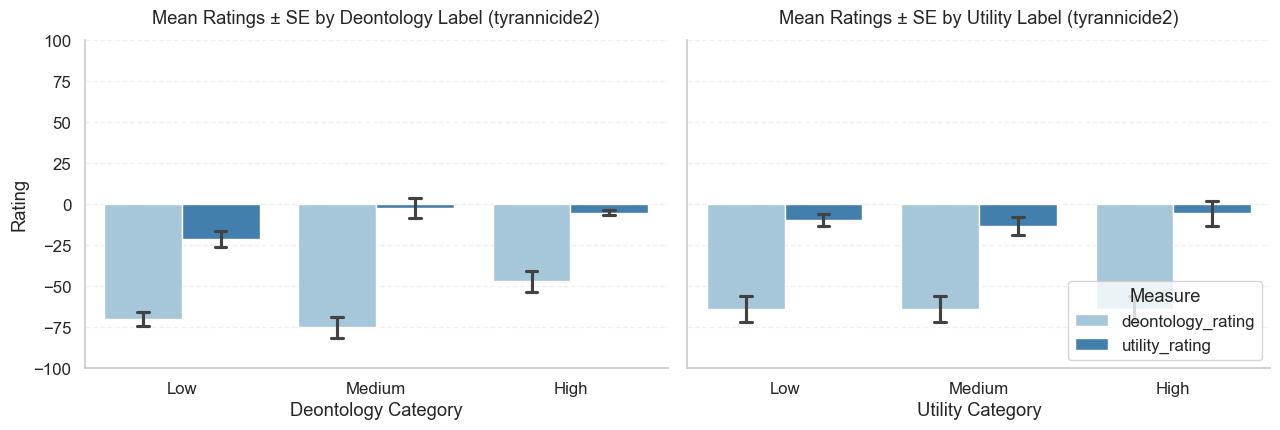

In [98]:
analysis_utils.make_deont_util_plot(scenario_name, plot_df, plots_path)